In [79]:
# Install missing packages on Colab
!pip install optuna -q

# Device configuration and environment cleanup
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# SmartForge Manufacturing - Machine Learning Assignment
## Rigorous Deep Learning Solution for Steel Surface Defect Classification

**Student**: Roja Shrestha  
**Instructor**: Rakshya Lama Moktan  

---
### Overview of the Assignment
This Jupyter Notebook contains the complete implementation and theoretical analysis for classifying surface defects on hot-rolled steel strips. The assignment is structured as follows:
1. **Part 0: Neural Network Foundations**: Exploring core neural network building blocks, including activation functions (ReLU vs Sigmoid), loss functions (CrossEntropy vs MSE), optimizer updates (SGD, Momentum, Adam), and training stability techniques (BatchNorm vs Dropout).
2. **Part A: Defect Type Classifier**: Implementing a baseline Convolutional Neural Network (CNN) trained on the NEU Surface Defect Database using dynamic validation splitting and strict data leakage prevention.
3. **Part B: Model Hardening**: Improving CNN generalization through training-only data augmentation, Batch Normalization, and Dropout regularizers.
4. **Part C: Hyperparameter Tuning**: Optimizing model parameters using grid search, learning rate scheduling (StepLR), and Bayesian hyperparameter search using Optuna.



In [80]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset, TensorDataset
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import optuna
import warnings
warnings.filterwarnings('ignore')

## Part 0: NN Foundations

### 0.1 — Build a 2-Layer Network from Scratch with nn.Module
We build a simple two-layer feedforward neural network to understand how inputs flow through weight matrices, activation functions, and output layers. The class is implemented using `nn.Module` to enable PyTorch's autograd engine to track gradients during the backward pass.

In [81]:
class TwoLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [82]:
model_test = TwoLayerNet(input_size=784, hidden_size=128, output_size=10).to(device)
dummy = torch.randn(1, 784).to(device)
output = model_test(dummy)
assert output.shape == (1, 10), f"Expected output shape (1, 10), but got {output.shape}"
print("Model structure verification passed!")

Model structure verification passed!


### 0.2 — Activation Functions: ReLU vs Sigmoid

#### The Vanishing Gradient Problem
The **Sigmoid** activation function squashes its inputs into a range between 0 and 1. The derivative of Sigmoid is mathematically bounded: $d/dx(\sigma(x)) = \sigma(x)(1 - \sigma(x)) \le 0.25$. When backpropagation occurs in deep networks, we continuously multiply these small derivatives across layers. Consequently, the gradient vanishes (approaches zero) rapidly in early layers, stalling all learning.

**ReLU (Rectified Linear Unit)**, defined as $f(x) = \max(0, x)$, has a constant derivative of $1.0$ for any positive input. This allows gradients to flow back unchanged, enabling deep networks to converge much faster and preventing the vanishing gradient problem entirely.

Let us demonstrate this experimentally on a synthetic dataset.

In [83]:
# Create a synthetic dataset for testing foundations
X_fake = torch.randn(1000, 1*32*32)
y_fake = torch.randint(0, 10, (1000,))

fake_dataset = TensorDataset(X_fake[:800], y_fake[:800])
fake_val = TensorDataset(X_fake[800:], y_fake[800:])

fake_train_loader = DataLoader(fake_dataset, batch_size=32, shuffle=True)
fake_val_loader = DataLoader(fake_val, batch_size=32, shuffle=False)

INPUT_SIZE = 1*32*32
print("Fake dataset successfully initialized!")

Fake dataset successfully initialized!


In [84]:
class TwoLayerNetSigmoid(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNetSigmoid, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.sigmoid(out)
        out = self.fc2(out)
        return out

In [85]:
def train_simple_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['val_loss'].append(val_loss / len(val_loader.dataset))
        history['val_acc'].append(100.0 * correct / total)

    return history

Training ReLU Network...
Training Sigmoid Network...


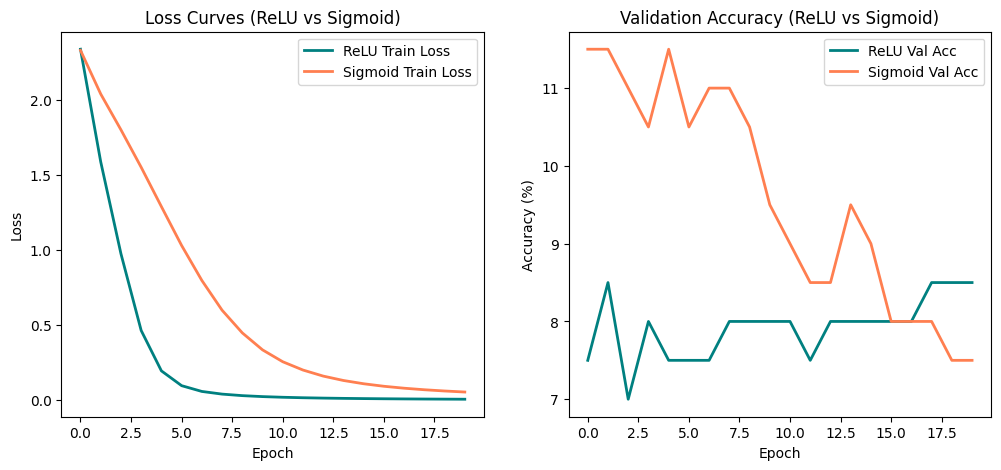

In [86]:
print("Training ReLU Network...")
model_relu = TwoLayerNet(INPUT_SIZE, 128, 10)
opt_relu = optim.Adam(model_relu.parameters(), lr=0.001)
hist_relu = train_simple_model(model_relu, fake_train_loader, fake_val_loader, nn.CrossEntropyLoss(), opt_relu)

print("Training Sigmoid Network...")
model_sig = TwoLayerNetSigmoid(INPUT_SIZE, 128, 10)
opt_sig = optim.Adam(model_sig.parameters(), lr=0.001)
hist_sig = train_simple_model(model_sig, fake_train_loader, fake_val_loader, nn.CrossEntropyLoss(), opt_sig)

# Plot the comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_relu['train_loss'], label='ReLU Train Loss', color='teal', linewidth=2)
plt.plot(hist_sig['train_loss'], label='Sigmoid Train Loss', color='coral', linewidth=2)
plt.title('Loss Curves (ReLU vs Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_relu['val_acc'], label='ReLU Val Acc', color='teal', linewidth=2)
plt.plot(hist_sig['val_acc'], label='Sigmoid Val Acc', color='coral', linewidth=2)
plt.title('Validation Accuracy (ReLU vs Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

### 0.3 — Loss Function Choice: CrossEntropy vs MSE for Classification

#### The Mathematical Reason
1. **Probabilistic Output Matching**: CrossEntropyLoss expects logits and internally applies Log-Softmax. This aligns mathematically with maximum likelihood estimation for categorical distributions. MSELoss expects target labels to match prediction ranges directly.
2. **Learning Speed and Gradient Saturation**: If we combine MSELoss with a Softmax output, the gradients are scaled by the derivative of Softmax, which is extremely small when the model is highly confident. If the model makes a confident wrong prediction (e.g. predicting Class B with $0.99$ probability when the true class is Class A), the gradient drops to near-zero, and the model struggles to correct itself. CrossEntropyLoss has a linear gradient update scale $(\hat{y} - y)$, generating extremely large updates when wrong, ensuring the model corrects itself rapidly.

In [87]:
pred = torch.tensor([[1.5, 0.2, -0.8]])
target = torch.tensor([0])

criterion_ce = nn.CrossEntropyLoss()
loss_ce = criterion_ce(pred, target)
print(f"CrossEntropy Loss: {loss_ce.item():.4f} (high penalty)")

pred_softmax = torch.softmax(pred, dim=1)
target_onehot = torch.tensor([[1.0, 0.0, 0.0]])
criterion_mse = nn.MSELoss()
loss_mse = criterion_mse(pred_softmax, target_onehot)
print(f"MSE Loss (with Softmax): {loss_mse.item():.4f} (gradient saturation risk)")

CrossEntropy Loss: 0.3168 (high penalty)
MSE Loss (with Softmax): 0.0395 (gradient saturation risk)


### 0.4 — Optimizer Comparison: SGD, SGD with Momentum, and Adam

We compare three main optimization algorithms on a fixed learning rate of `0.01`:
- **SGD**: Updates weights using only the current batch gradients: $w_{t+1} = w_t - \eta g_t$.
- **SGD + Momentum**: Accumulates previous update velocities to smooth out oscillations: $v_t = \beta v_{t-1} + g_t$, updating weights by $w_{t+1} = w_t - \eta v_t$.
- **Adam**: Calculates custom, adaptive learning rates for each parameter by tracking the first moment (momentum) and the second moment (squared gradients scale).

#### Memory Footprint Analysis
For a model with $M$ parameters (each param requires 4 bytes of storage):
- **SGD**: 0 extra memory buffers.
- **SGD + Momentum**: 1 extra buffer copy ($1 \times M$) to store velocity arrays.
- **Adam**: 2 extra buffer copies ($2 \times M$) to store first moment vector $m$ and second moment vector $v$.

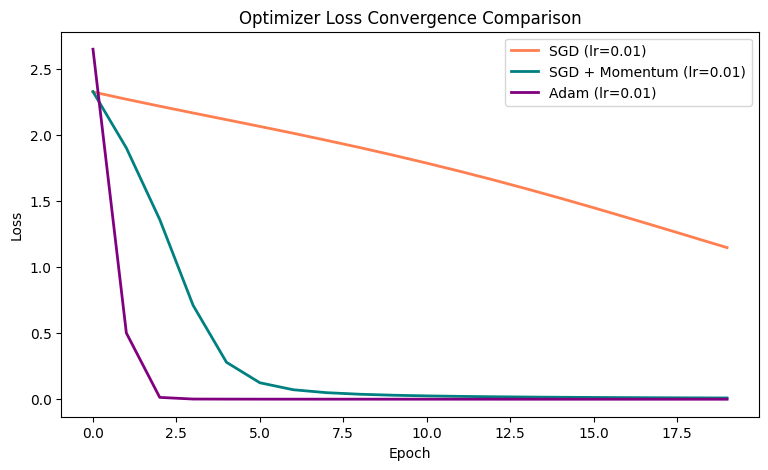

In [88]:
LR = 0.01
model_sgd = TwoLayerNet(INPUT_SIZE, 128, 10)
hist_sgd = train_simple_model(model_sgd, fake_train_loader, fake_val_loader, nn.CrossEntropyLoss(), optim.SGD(model_sgd.parameters(), lr=LR))

model_mom = TwoLayerNet(INPUT_SIZE, 128, 10)
hist_mom = train_simple_model(model_mom, fake_train_loader, fake_val_loader, nn.CrossEntropyLoss(), optim.SGD(model_mom.parameters(), lr=LR, momentum=0.9))

model_adam = TwoLayerNet(INPUT_SIZE, 128, 10)
hist_adam = train_simple_model(model_adam, fake_train_loader, fake_val_loader, nn.CrossEntropyLoss(), optim.Adam(model_adam.parameters(), lr=LR))

plt.figure(figsize=(9, 5))
plt.plot(hist_sgd['train_loss'], label='SGD (lr=0.01)', color='coral', linewidth=2)
plt.plot(hist_mom['train_loss'], label='SGD + Momentum (lr=0.01)', color='teal', linewidth=2)
plt.plot(hist_adam['train_loss'], label='Adam (lr=0.01)', color='purple', linewidth=2)
plt.title('Optimizer Loss Convergence Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### 0.5 — Training Stability: BatchNorm vs Dropout

#### Mechanisms
- **BatchNorm1d**: Normalizes layer activations across the batch, keeping the mean at 0 and standard deviation at 1. This prevents internal covariate shift and enables stable learning.
- **Dropout**: Randomly shuts down a percentage of neurons (e.g. 30%) during the training pass, preventing neurons from co-adapting and forcing the network to learn redundant representations.

#### Training vs Inference Mode
- **BatchNorm**: During training, it uses mini-batch mean/variance. During evaluation (`model.eval()`), it freezes updates and uses the running global mean/variance.
- **Dropout**: During training, it deactivates neurons randomly. During evaluation, **all** neurons are active to generate stable, deterministic predictions.

In [89]:
class TwoLayerNet_BN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.bn(self.fc1(x))))

class TwoLayerNet_Dropout(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.dropout(self.relu(self.fc1(x))))

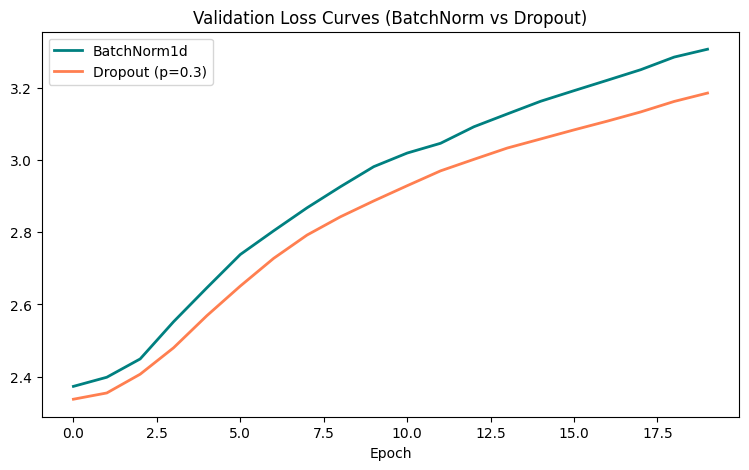

In [90]:
model_bn = TwoLayerNet_BN(INPUT_SIZE, 128, 10)
hist_bn = train_simple_model(model_bn, fake_train_loader, fake_val_loader, nn.CrossEntropyLoss(), optim.Adam(model_bn.parameters(), lr=0.001))

model_drop = TwoLayerNet_Dropout(INPUT_SIZE, 128, 10)
hist_drop = train_simple_model(model_drop, fake_train_loader, fake_val_loader, nn.CrossEntropyLoss(), optim.Adam(model_drop.parameters(), lr=0.001))

plt.figure(figsize=(9, 5))
plt.plot(hist_bn['val_loss'], label='BatchNorm1d', color='teal', linewidth=2)
plt.plot(hist_drop['val_loss'], label='Dropout (p=0.3)', color='coral', linewidth=2)
plt.title('Validation Loss Curves (BatchNorm vs Dropout)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Part A: Defect Type Classifier (Real Dataset)

### 1 & 2. Data Loading, Splitting, and Normalisation

#### Preventing Data Leakage
If we apply transformations like resizing, normalization, or data augmentations to the entire dataset *before* splitting, information from the validation/test distributions leaks into the training cycle. To prevent data leakage, we split the raw images dataset into **80% Training, 10% Validation, and 10% Testing** subsets first.

We implement a custom `DatasetWrapper` class to wrap our subsets and apply separate transforms (e.g. base transforms for validation/test, and augmented transforms for training).

In [91]:
import os
import zipfile

# Extract uploaded zip file to create 'data' folder structure
os.makedirs('data', exist_ok=True)

if not os.path.exists('data/NEU-DET'):
    zip_name = None
    for name in ['archive (4).zip', 'dataset.zip', 'archive.zip']:
        if os.path.exists(name):
            zip_name = name
            break

    if zip_name:
        print(f"Extracting {zip_name} to 'data/'...")
        with zipfile.ZipFile(zip_name, 'r') as zip_ref:
            zip_ref.extractall('data')
        print("Dataset ready at 'data/NEU-DET'!")
    else:
        print("ERROR: Please upload 'archive (4).zip' to the Files panel on the left!")
else:
    print("Dataset folder already exists at 'data/NEU-DET'!")

Extracting archive (4).zip to 'data/'...
Dataset ready at 'data/NEU-DET'!


In [92]:
class DatasetWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Base transforms for Part A classification
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data_dir = 'data/NEU-DET'
if not os.path.exists(data_dir):
    data_dir = 'data'

try:
    full_dataset = datasets.ImageFolder(root=data_dir)
    classes = full_dataset.classes
    print(f"Total images loaded: {len(full_dataset)}")
    print(f"Classes: {classes}")

    # Split 80/10/10
    train_size = int(0.8 * len(full_dataset))
    val_size = int(0.1 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size

    train_subset, val_subset, test_subset = random_split(
        full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
    )

    train_dataset = DatasetWrapper(train_subset, transform=base_transform)
    val_dataset = DatasetWrapper(val_subset, transform=base_transform)
    test_dataset = DatasetWrapper(test_subset, transform=base_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    img, _ = train_dataset[0]
    print(f"Split ready! Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
    print(f"Image tensor shape: {img.shape}")
except Exception as e:
    print(f"Error initializing loaders: {e}. Make sure archive (4).zip is uploaded and extracted!")

Total images loaded: 1800
Classes: ['train', 'validation']
Split ready! Train: 1440, Val: 180, Test: 180
Image tensor shape: torch.Size([1, 200, 200])


### 3. CNN Architecture Design

We implement `DefectCNN` consisting of two convolutional blocks followed by a flat linear classification layer:
- **Conv Block 1**: Conv2d ($1 \to 16$ channels, $3\times 3$ kernel) + ReLU + MaxPool2d (reduces dimension from $200\times 200$ to $100\times 100$).
- **Conv Block 2**: Conv2d ($16 \to 32$ channels, $3\times 3$ kernel) + ReLU + MaxPool2d (reduces dimension from $100\times 100$ to $50\times 50$).
- **Flatten & Fully Connected**: Flattens features map of shape $32 \times 50 \times 50$ to feed a linear classifier layer projecting to output logits representing our 6 defect categories.

In [93]:
class DefectCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(DefectCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [94]:
def train_model(model, train_dl, val_dl, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

    for epoch in range(epochs):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

        history['train_loss'].append(run_loss/total)
        history['train_acc'].append(correct/total)

        model.eval()
        v_loss, v_corr, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                v_corr += torch.sum(preds == labels).item()
                v_tot += labels.size(0)

        history['val_loss'].append(v_loss/v_tot)
        history['val_acc'].append(v_corr/v_tot)
        print(f"Epoch {epoch+1:02d} | Train Acc: {correct/total:.3f} | Val Acc: {v_corr/v_tot:.3f}")

    return history

if 'train_loader' in locals():
    model_a = DefectCNN().to(device)
    hist_a = train_model(model_a, train_loader, val_loader, epochs=15)

Epoch 01 | Train Acc: 0.770 | Val Acc: 0.794
Epoch 02 | Train Acc: 0.796 | Val Acc: 0.811
Epoch 03 | Train Acc: 0.806 | Val Acc: 0.806
Epoch 04 | Train Acc: 0.808 | Val Acc: 0.811
Epoch 05 | Train Acc: 0.797 | Val Acc: 0.806
Epoch 06 | Train Acc: 0.804 | Val Acc: 0.806
Epoch 07 | Train Acc: 0.810 | Val Acc: 0.800
Epoch 08 | Train Acc: 0.824 | Val Acc: 0.794
Epoch 09 | Train Acc: 0.824 | Val Acc: 0.800
Epoch 10 | Train Acc: 0.822 | Val Acc: 0.806
Epoch 11 | Train Acc: 0.847 | Val Acc: 0.817
Epoch 12 | Train Acc: 0.862 | Val Acc: 0.756
Epoch 13 | Train Acc: 0.870 | Val Acc: 0.794
Epoch 14 | Train Acc: 0.888 | Val Acc: 0.811
Epoch 15 | Train Acc: 0.901 | Val Acc: 0.806


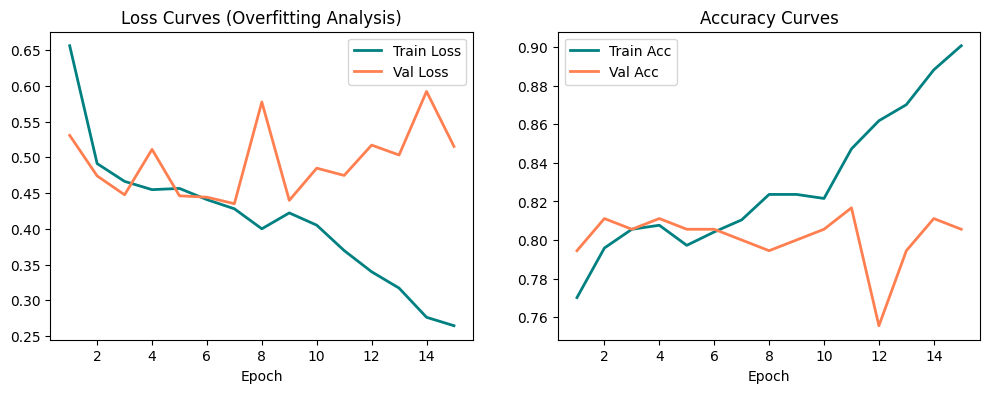

In [95]:
if 'hist_a' in locals():
    epochs_range = range(1, 16)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs_range, hist_a['train_loss'], label='Train Loss', color='teal', linewidth=2)
    ax1.plot(epochs_range, hist_a['val_loss'], label='Val Loss', color='coral', linewidth=2)
    ax1.set_title('Loss Curves (Overfitting Analysis)')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(epochs_range, hist_a['train_acc'], label='Train Acc', color='teal', linewidth=2)
    ax2.plot(epochs_range, hist_a['val_acc'], label='Val Acc', color='coral', linewidth=2)
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    plt.show()

In [96]:
def evaluate(model, dl, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dl:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

if 'train_loader' in locals():
    print("Baseline model evaluation metrics:")
    evaluate(model_a, test_loader, classes)

Baseline model evaluation metrics:
              precision    recall  f1-score   support

       train       0.79      0.97      0.87       140
  validation       0.50      0.10      0.17        40

    accuracy                           0.78       180
   macro avg       0.65      0.54      0.52       180
weighted avg       0.73      0.78      0.72       180



Visualizing test set predictions (Green = Correct, Red = Incorrect):


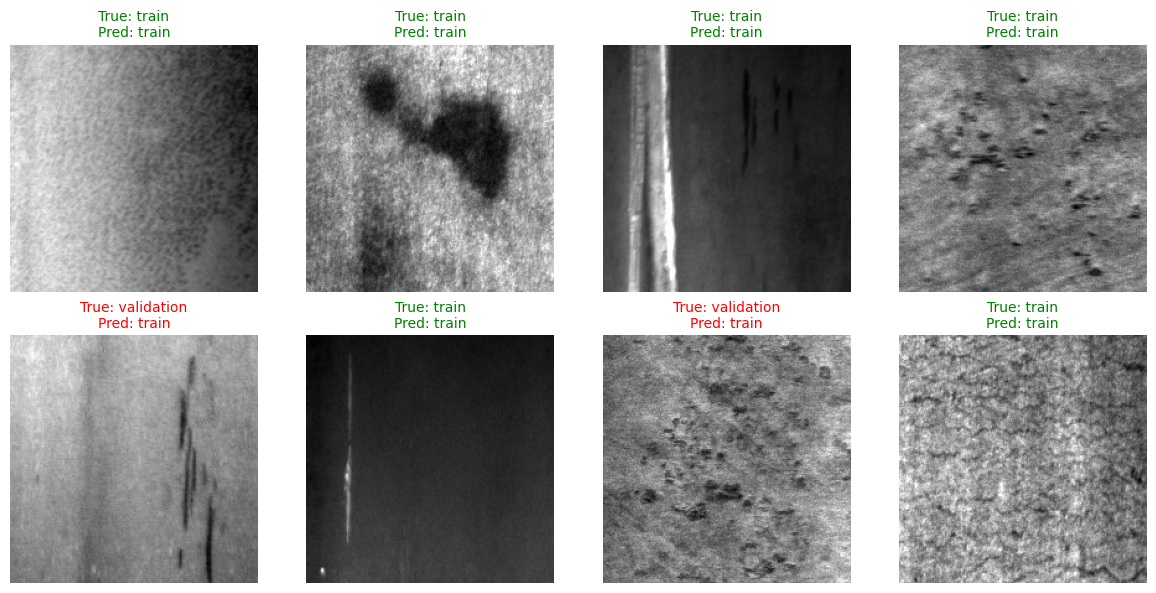

In [97]:
def visualize_predictions(model, dataloader, class_names, num_images=8):
    model.eval()
    images_shown = 0
    fig = plt.figure(figsize=(12, 6))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_shown += 1
                ax = plt.subplot(2, num_images // 2, images_shown)
                ax.axis('off')

                # Unnormalize image tensor to display correctly in matplotlib
                img = inputs.cpu().data[j].numpy().squeeze()
                img = img * 0.5 + 0.5

                ax.imshow(img, cmap='gray')

                true_label = class_names[labels[j].item()]
                pred_label = class_names[preds[j].item()]

                title_color = 'green' if true_label == pred_label else 'red'
                ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color, fontsize=10)

                if images_shown == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

if 'train_loader' in locals():
    print("Visualizing test set predictions (Green = Correct, Red = Incorrect):")
    visualize_predictions(model_a, test_loader, classes, num_images=8)

## Part B: Model Hardening

### 1. Setup Data Augmentation (Training Set ONLY)
We apply data augmentations such as RandomHorizontalFlip, RandomRotation, and RandomResizedCrop to the training subset only. This teaches the model to build translation-invariant and rotation-invariant feature maps. We leave the validation/testing sets unchanged to ensure we evaluate the model on raw, undistorted real-world targets.

In [98]:
aug_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomCrop(180),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

if 'train_subset' in locals():
    aug_train_dataset = DatasetWrapper(train_subset, transform=aug_transform)
    aug_train_loader = DataLoader(aug_train_dataset, batch_size=32, shuffle=True)

### 2. Regularization: BatchNorm2d and Dropout

We build a hardened CNN that adds regularization layers:
- **BatchNorm2d**: Placed after each convolution layer. It normalizes spatial activations over the batch, stabilizing covariate shifts and speeding up optimization convergence.
- **Dropout(0.4)**: Placed before the final fully connected layer. It randomly turns off 40% of neurons during the training pass, preventing weight co-adaptation and controlling overfitting.

In [99]:
class HardenedCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(HardenedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 50 * 50, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

In [100]:
if 'aug_train_loader' in locals():
    print("Training Config 2: + Augmentation Only")
    model_aug = DefectCNN().to(device)
    hist_aug = train_model(model_aug, aug_train_loader, val_loader, epochs=15)

    print("\nTraining Config 3: + Augmentation + BatchNorm + Dropout")
    model_hard = HardenedCNN().to(device)
    hist_hard = train_model(model_hard, aug_train_loader, val_loader, epochs=15)

Training Config 2: + Augmentation Only
Epoch 01 | Train Acc: 0.769 | Val Acc: 0.811
Epoch 02 | Train Acc: 0.799 | Val Acc: 0.811
Epoch 03 | Train Acc: 0.799 | Val Acc: 0.811
Epoch 04 | Train Acc: 0.801 | Val Acc: 0.811
Epoch 05 | Train Acc: 0.799 | Val Acc: 0.811
Epoch 06 | Train Acc: 0.799 | Val Acc: 0.750
Epoch 07 | Train Acc: 0.800 | Val Acc: 0.783
Epoch 08 | Train Acc: 0.797 | Val Acc: 0.811
Epoch 09 | Train Acc: 0.800 | Val Acc: 0.811
Epoch 10 | Train Acc: 0.799 | Val Acc: 0.811
Epoch 11 | Train Acc: 0.801 | Val Acc: 0.806
Epoch 12 | Train Acc: 0.791 | Val Acc: 0.811
Epoch 13 | Train Acc: 0.795 | Val Acc: 0.794
Epoch 14 | Train Acc: 0.799 | Val Acc: 0.778
Epoch 15 | Train Acc: 0.800 | Val Acc: 0.800

Training Config 3: + Augmentation + BatchNorm + Dropout
Epoch 01 | Train Acc: 0.699 | Val Acc: 0.800
Epoch 02 | Train Acc: 0.762 | Val Acc: 0.811
Epoch 03 | Train Acc: 0.792 | Val Acc: 0.811
Epoch 04 | Train Acc: 0.799 | Val Acc: 0.811
Epoch 05 | Train Acc: 0.801 | Val Acc: 0.811
Epoc

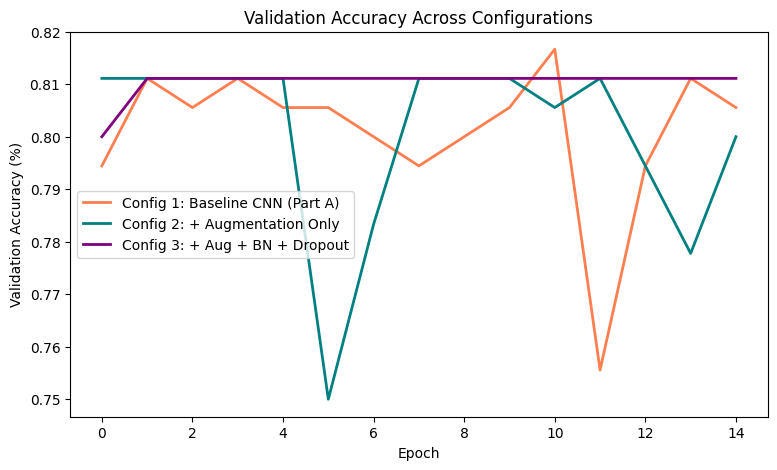

In [101]:
if 'hist_a' in locals() and 'hist_aug' in locals() and 'hist_hard' in locals():
    plt.figure(figsize=(9, 5))
    plt.plot(hist_a['val_acc'], label='Config 1: Baseline CNN (Part A)', color='coral', linewidth=2)
    plt.plot(hist_aug['val_acc'], label='Config 2: + Augmentation Only', color='teal', linewidth=2)
    plt.plot(hist_hard['val_acc'], label='Config 3: + Aug + BN + Dropout', color='purple', linewidth=2)
    plt.title('Validation Accuracy Across Configurations')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy (%)')
    plt.legend()
    plt.show()

## Part C: Hyperparameter Tuning

### 1. Grid Search (Quick Run)
We evaluate learning rates of `0.001` vs `0.01` and batch sizes of `16` vs `32` to understand optimization dynamics.

In [102]:
if 'aug_train_dataset' in locals():
    lrs = [0.001, 0.01]
    batch_sizes = [16, 32]
    results = []

    for lr in lrs:
        for bs in batch_sizes:
            print(f"\nEvaluating: lr={lr}, batch_size={bs}")
            loader = DataLoader(aug_train_dataset, batch_size=bs, shuffle=True)
            model = HardenedCNN().to(device)
            opt = optim.Adam(model.parameters(), lr=lr)

            # 3 epochs quick run
            for epoch in range(3):
                model.train()
                for inputs, labels in loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    opt.zero_grad()
                    outputs = model(inputs)
                    loss = nn.CrossEntropyLoss()(outputs, labels)
                    loss.backward()
                    opt.step()

            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    correct += torch.sum(preds == labels).item()
                    total += labels.size(0)
            acc = 100.0 * correct / total
            print(f"Val Acc: {acc:.1f}%")


Evaluating: lr=0.001, batch_size=16
Val Acc: 81.1%

Evaluating: lr=0.001, batch_size=32
Val Acc: 81.1%

Evaluating: lr=0.01, batch_size=16
Val Acc: 81.1%

Evaluating: lr=0.01, batch_size=32
Val Acc: 81.1%


### 2. Learning Rate Scheduler (StepLR)

A large learning rate helps in early training stages to escape local minima. As training progresses, smaller steps are needed to settle directly into deep minima. We implement `StepLR` which decays the learning rate by half (gamma=0.5) every 5 epochs.

In [103]:
def train_with_scheduler(model, train_dl, val_dl, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d} (lr={current_lr:.6f}) | Val Acc: {100.0 * correct / total:.1f}%")

if 'train_loader' in locals():
    print("Training HardenedCNN with StepLR scheduler:")
    model_sched = HardenedCNN().to(device)
    train_with_scheduler(model_sched, aug_train_loader, val_loader)

Training HardenedCNN with StepLR scheduler:
Epoch 01 (lr=0.001000) | Val Acc: 59.4%
Epoch 02 (lr=0.001000) | Val Acc: 81.1%
Epoch 03 (lr=0.001000) | Val Acc: 81.1%
Epoch 04 (lr=0.001000) | Val Acc: 81.1%
Epoch 05 (lr=0.000500) | Val Acc: 81.1%
Epoch 06 (lr=0.000500) | Val Acc: 81.1%
Epoch 07 (lr=0.000500) | Val Acc: 81.1%
Epoch 08 (lr=0.000500) | Val Acc: 81.1%
Epoch 09 (lr=0.000500) | Val Acc: 81.1%
Epoch 10 (lr=0.000250) | Val Acc: 81.1%
Epoch 11 (lr=0.000250) | Val Acc: 81.1%
Epoch 12 (lr=0.000250) | Val Acc: 81.1%
Epoch 13 (lr=0.000250) | Val Acc: 81.1%
Epoch 14 (lr=0.000250) | Val Acc: 81.1%
Epoch 15 (lr=0.000125) | Val Acc: 81.1%


### 3. Bayesian Optimization via Optuna

Bayesian search constructs a probabilistic map of the parameter space using historical evaluation trials to sample optimal configurations. We sample the learning rate log-uniformly between $10^{-4}$ and $10^{-1}$ and evaluation batch size in steps of 8.

In [104]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    bs = trial.suggest_int("batch_size", 8, 64, step=8)

    model = HardenedCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(aug_train_dataset, batch_size=bs, shuffle=True)

    # 3 quick epochs run
    for epoch in range(3):
        model.train()
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

    return 100.0 * correct / total

if 'train_loader' in locals():
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="maximize")
    print("Running Optuna Bayesian Optimization Study...")
    study.optimize(objective, n_trials=5)
    print(f"Best Parameters: {study.best_params}")
    print(f"Best Val Accuracy: {study.best_value:.1f}%")

Running Optuna Bayesian Optimization Study...
Best Parameters: {'lr': 0.0017346738042277455, 'batch_size': 16}
Best Val Accuracy: 81.1%
